In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math


In [3]:
transform_base = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_base)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [4]:
augmentations = {
    "ResizeCrop": transforms.RandomResizedCrop(32),
    "HorizontalFlip": transforms.RandomHorizontalFlip(p=1.0),
    "VerticalFlip": transforms.RandomVerticalFlip(p=1.0),
    "Rotation": transforms.RandomRotation(30),
    "ColorJitter": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    "Grayscale": transforms.RandomGrayscale(p=1.0),
    "GaussianBlur": transforms.GaussianBlur(kernel_size=3),
    "Cutout": transforms.RandomErasing(p=1.0),
    "Affine": transforms.RandomAffine(degrees=20, translate=(0.1,0.1), scale=(0.8,1.2)),
}


In [5]:
def mixup_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size)
    cut_w = int(w * math.sqrt(1 - lam))
    cut_h = int(h * math.sqrt(1 - lam))
    cx, cy = torch.randint(w, (1,)), torch.randint(h, (1,))
    x1, y1 = max(cx - cut_w // 2, 0), max(cy - cut_h // 2, 0)
    x2, y2 = min(cx + cut_w // 2, w), min(cy + cut_h // 2, h)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    y_a, y_b = y, y[index]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y_a, y_b, lam


In [6]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [7]:
def train_model(train_loader, test_loader, augmentation=None, epochs=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_acc_list, test_acc_list = [], []
    
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            if augmentation == "mixup":
                images, y_a, y_b, lam = mixup_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            elif augmentation == "cutmix":
                images, y_a, y_b, lam = cutmix_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        train_acc_list.append(train_acc)
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        test_acc = 100. * correct / total
        test_acc_list.append(test_acc)
        
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")
    
    return train_acc_list, test_acc_list


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


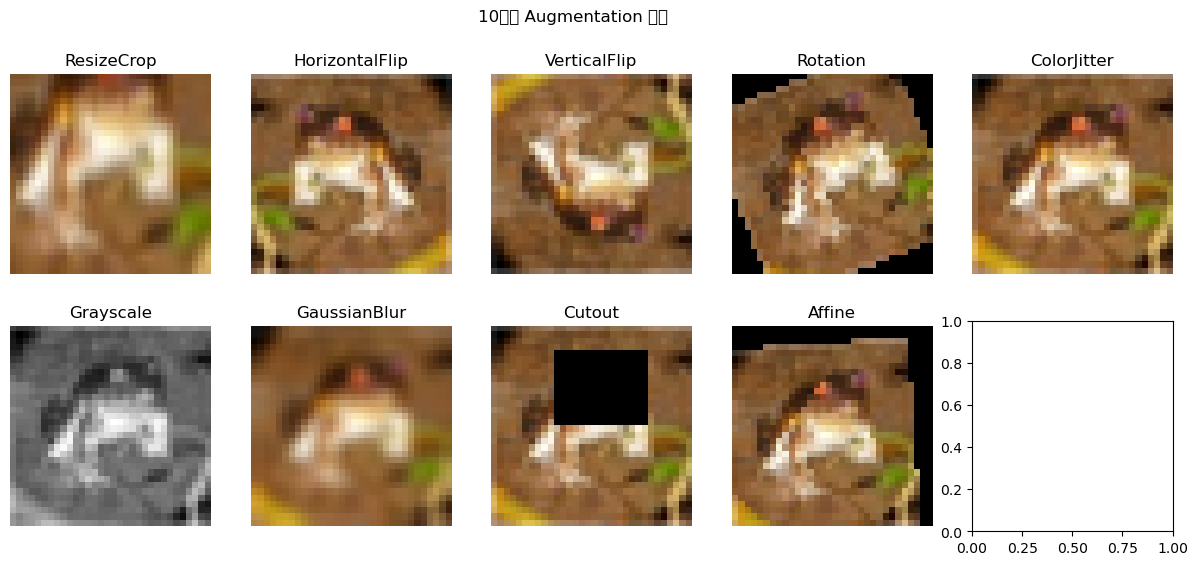

In [8]:
import numpy as np

# CIFAR-10 샘플 이미지 하나 가져오기
sample_img, _ = train_dataset[0]

fig, axes = plt.subplots(2, 5, figsize=(15,6))
for ax, (name, aug) in zip(axes.flatten(), augmentations.items()):
    img = aug(sample_img)
    img = img.permute(1, 2, 0).numpy()
    ax.imshow((img - img.min()) / (img.max() - img.min()))
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("10가지 Augmentation 예시")
plt.show()


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math
import numpy as np


In [10]:
transform_base = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_base)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [11]:
augmentations = {
    "ResizeCrop": transforms.RandomResizedCrop(32),
    "HorizontalFlip": transforms.RandomHorizontalFlip(p=1.0),
    "VerticalFlip": transforms.RandomVerticalFlip(p=1.0),
    "Rotation": transforms.RandomRotation(30),
    "ColorJitter": transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
    "Grayscale": transforms.RandomGrayscale(p=1.0),
    "GaussianBlur": transforms.GaussianBlur(kernel_size=3),
    "Cutout": transforms.RandomErasing(p=1.0),
    "Affine": transforms.RandomAffine(degrees=20, translate=(0.1,0.1), scale=(0.8,1.2)),
}


In [12]:
def mixup_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_data(x, y, alpha=1.0):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size, _, h, w = x.size()
    index = torch.randperm(batch_size)
    cut_w = int(w * math.sqrt(1 - lam))
    cut_h = int(h * math.sqrt(1 - lam))
    cx, cy = torch.randint(w, (1,)), torch.randint(h, (1,))
    x1, y1 = max(cx - cut_w // 2, 0), max(cy - cut_h // 2, 0)
    x2, y2 = min(cx + cut_w // 2, w), min(cy + cut_h // 2, h)
    x[:, :, y1:y2, x1:x2] = x[index, :, y1:y2, x1:x2]
    y_a, y_b = y, y[index]
    lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))
    return x, y_a, y_b, lam


In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64*8*8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


In [14]:
def train_model(train_loader, test_loader, augmentation=None, epochs=2):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_acc_list, test_acc_list = [], []
    
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            if augmentation == "mixup":
                images, y_a, y_b, lam = mixup_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            elif augmentation == "cutmix":
                images, y_a, y_b, lam = cutmix_data(images, labels)
                outputs = model(images)
                loss = lam * criterion(outputs, y_a) + (1 - lam) * criterion(outputs, y_b)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        train_acc = 100. * correct / total
        train_acc_list.append(train_acc)
        
        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        test_acc = 100. * correct / total
        test_acc_list.append(test_acc)
        
        print(f"Epoch {epoch+1}: Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%")
    
    return train_acc_list, test_acc_list


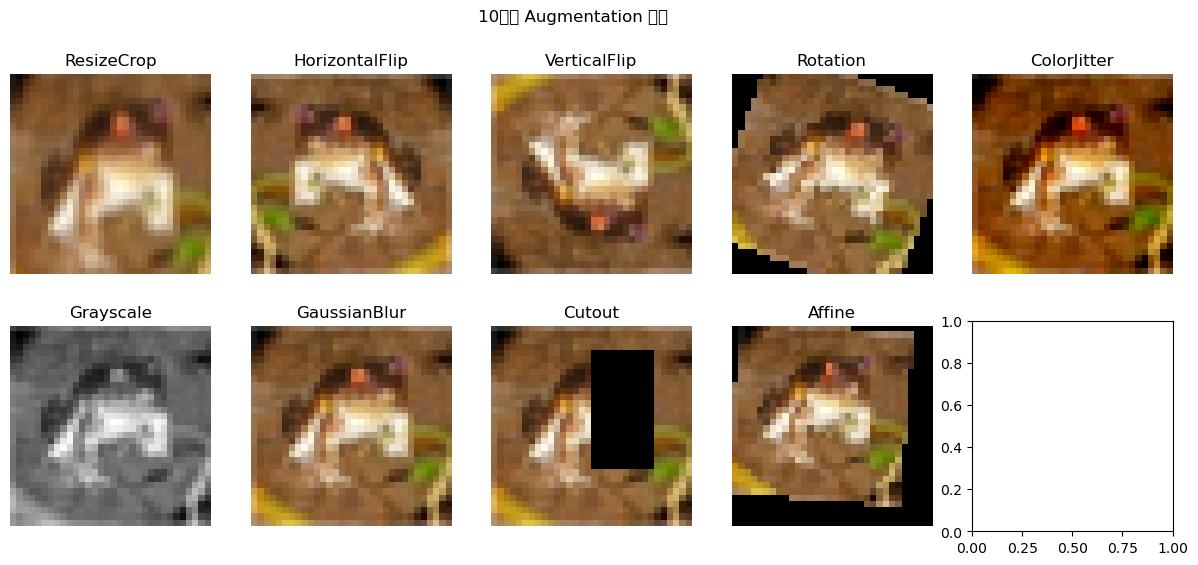

In [15]:
sample_img, _ = train_dataset[0]

fig, axes = plt.subplots(2, 5, figsize=(15,6))
for ax, (name, aug) in zip(axes.flatten(), augmentations.items()):
    img = aug(sample_img)
    img = img.permute(1, 2, 0).numpy()
    ax.imshow((img - img.min()) / (img.max() - img.min()))
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("10가지 Augmentation 예시")
plt.show()


In [ ]:
acc_no_aug = train_model(train_loader, test_loader, augmentation=None)
acc_mixup = train_model(train_loader, test_loader, augmentation="mixup")
acc_cutmix = train_model(train_loader, test_loader, augmentation="cutmix")

epochs = range(1, 3)
plt.plot(epochs, acc_no_aug[1], 'r', label='No Augmentation')
plt.plot(epochs, acc_mixup[1], 'g', label='Mixup')
plt.plot(epochs, acc_cutmix[1], 'b', label='CutMix')
plt.title('Validation Accuracy Comparison (CIFAR-10)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()


In [ ]:
# CIFAR-10은 파일사이즈가 작아서....차이점을 제대로 알지 못해서 satanford 데이터를 이용해서 다시 실험을 하였다.